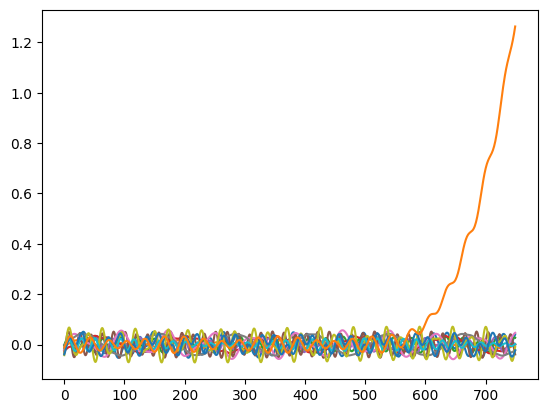

In [1]:
# Load data
import numpy as np
import matplotlib.pyplot as plt

def gen_timeseries(length=750, num_waves=2):
    base = (np.random.rand(1) - 0.5) * np.ones((length,))

    for _ in range(num_waves):
        base += np.sin(np.arange(length) * np.random.rand(1) * 0.4  - np.random.rand(1)) * np.random.rand(1) * 0.05

    return base

xs = []
for i in range(100):

    x = np.stack([gen_timeseries() for _ in range(12)])

    x -= np.mean(x, axis=1, keepdims=True)
    # x = np.std(x, axis=1, keepdims=True)

    x_pre = np.copy(x.T)

    drift = np.power(np.arange(250), 3) * (1/6) * 0.0000005
    x[11, -250:] = x[11, -250:] + np.expand_dims(drift, axis=0)

    x = x[:, np.all(np.isfinite(x), axis=0)].T

    
    xs.append(x)

plt.plot(x)
plt.show()

In [3]:
from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for sr in tqdm(np.linspace(0.2, 0.8, 10)[::-1]):
    for iw in np.linspace(0.25, 1.0, 10):
        for l in np.linspace(0.5, 0.95, 10):
            network = RhythmicNetwork(
                # Tune Rhythmic Sharing
                link_strength_change_ratio=0.5,
                omega0=0.05,
                epsilon1=-0.12,
                epsilon2=0.25,
                # Tune ESN
                input_dims=12,
                spectral_radius=sr,
                input_weight=iw,
                average_degree_nodes=5,
                num_nodes=75,
                leakage=l
            )

            network.train(x_pre.T[:, :-100])
            pred = network.predict(x_pre.T[:, -110:], warmup_time=10)
            mse = np.mean(np.square((pred[:, 1:] - x_pre.T[:, -100:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

New best 94.8819055587 (np.float64(0.8), np.float64(0.25), np.float64(0.5))
New best 74.1517212769 (np.float64(0.8), np.float64(0.3333333333333333), np.float64(0.5))
New best 73.1725321200 (np.float64(0.8), np.float64(0.3333333333333333), np.float64(0.55))
New best 41.3690314977 (np.float64(0.8), np.float64(0.41666666666666663), np.float64(0.5))
New best 29.0421458144 (np.float64(0.8), np.float64(0.5), np.float64(0.5))
New best 18.0931623576 (np.float64(0.8), np.float64(0.5833333333333333), np.float64(0.5))
New best 15.1779684666 (np.float64(0.8), np.float64(0.6666666666666666), np.float64(0.5))
New best 11.7633303134 (np.float64(0.8), np.float64(0.75), np.float64(0.5))
New best 8.7905945676 (np.float64(0.8), np.float64(0.8333333333333333), np.float64(0.5))
New best 8.7616431024 (np.float64(0.8), np.float64(0.9166666666666666), np.float64(0.5))
New best 7.2677068945 (np.float64(0.8), np.float64(1.0), np.float64(0.5))


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [06:14<00:00, 37.47s/it]


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

New best 0.3317703219 (np.float64(0.25), np.float64(-0.2), np.float64(0.6111111111111112), np.float64(1.0))


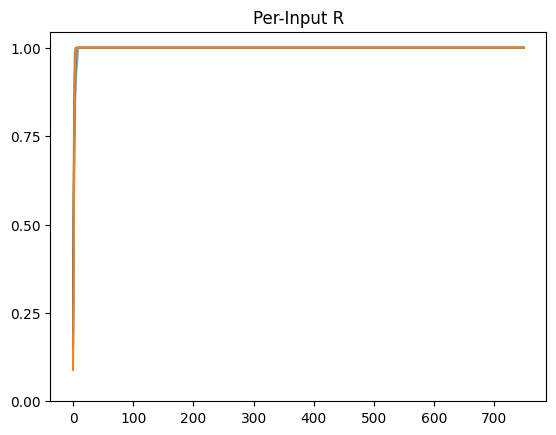

New best 0.6800204009 (np.float64(0.25), np.float64(-0.2), np.float64(0.6111111111111112), np.float64(0.001))


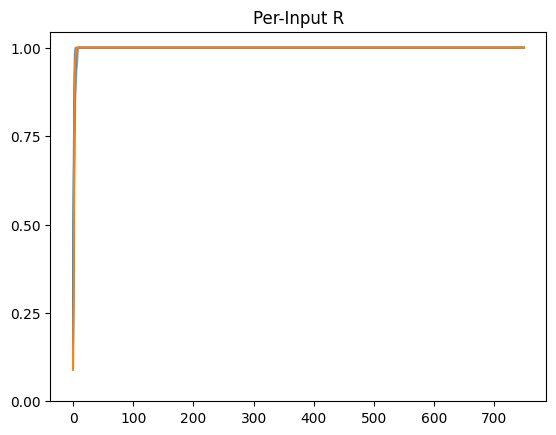

 10%|████████▎                                                                          | 1/10 [00:39<05:54, 39.34s/it]

New best 0.8091565808 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7222222222222222), np.float64(0.01))


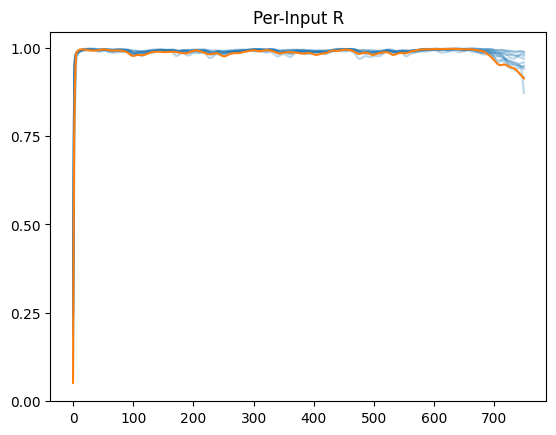

 30%|████████████████████████▉                                                          | 3/10 [01:58<04:37, 39.63s/it]

New best 1.3888201918 (np.float64(0.25), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(1.0))


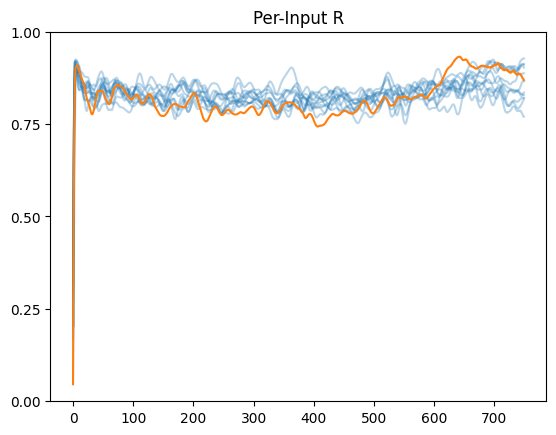

New best 2.4589947214 (np.float64(0.25), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(0.21544346900318823))


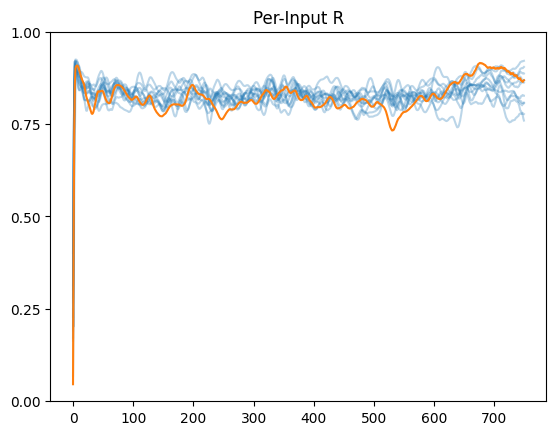

 80%|██████████████████████████████████████████████████████████████████▍                | 8/10 [05:12<01:18, 39.16s/it]

New best 2.7266143302 (np.float64(0.3333333333333333), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.046415888336127774))


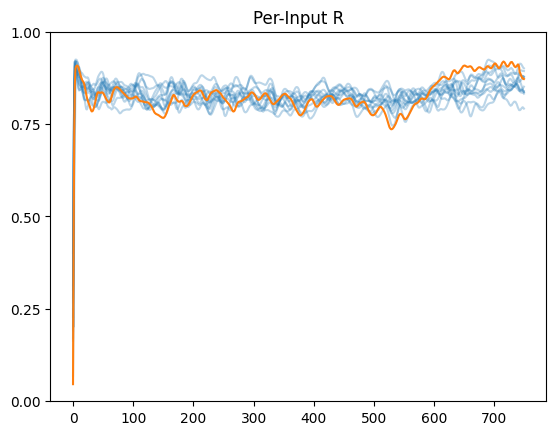

 40%|█████████████████████████████████▏                                                 | 4/10 [02:47<04:09, 41.63s/it]

New best 3.8712553918 (np.float64(0.41666666666666663), np.float64(-0.15555555555555556), np.float64(0.7222222222222222), np.float64(0.001))


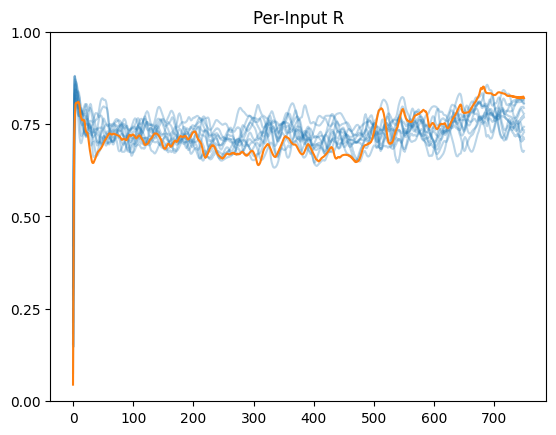

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [05:48<00:00, 34.86s/it]


In [4]:
best_difference = 0
for lsr in np.linspace(0.25, 1, 10):
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)):
        for o in np.logspace(-3, 0, 10)[::-1]:
            for e2 in np.linspace(0.5, 1.5, 10)[:-1]:
                network = RhythmicNetwork(
                    # Tune Rhythmic Sharing
                    dt=10,
                    link_strength_change_ratio = lsr,
                    omega0 = o,
                    epsilon1 = e1,
                    epsilon2 = e2,
                    # Set ESN
                    input_dims=12,
                    spectral_radius=best_esn_param[0],
                    input_weight=best_esn_param[1],
                    average_degree_nodes=5,
                    num_nodes=75,
                    leakage=best_esn_param[2],
                )

                network.train(x.T, warmup_time=0)
                r = network.get_input_parameters()[0]
    
                # diff = np.abs(np.mean(r.T[300:500, 11]) - np.mean(r.T[500:, 11])) #/np.mean(r.T[:250])
                diff = np.abs(np.mean(r.T[300:500, 11]) - np.mean(r.T[500:550, 11]))/np.std(r.T[300:500, 11])
                
                if diff > best_difference and np.mean(r.T[300:500]) > 0.7: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T[:, :11], color="tab:blue", alpha=0.3)
                    plt.plot(network.get_input_parameters()[0].T[:, 11], color="tab:orange")
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [5]:
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    link_strength_change_ratio = best_param_rhy[0],
    omega0 = best_param_rhy[3],
    epsilon1 = best_param_rhy[1],
    epsilon2 = best_param_rhy[2],
    # Set ESN
    input_dims=12,
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=5,
    num_nodes=75,
    leakage=best_esn_param[2],
)

network.train(x.T, warmup_time=0)
r = network.get_input_parameters()[0]

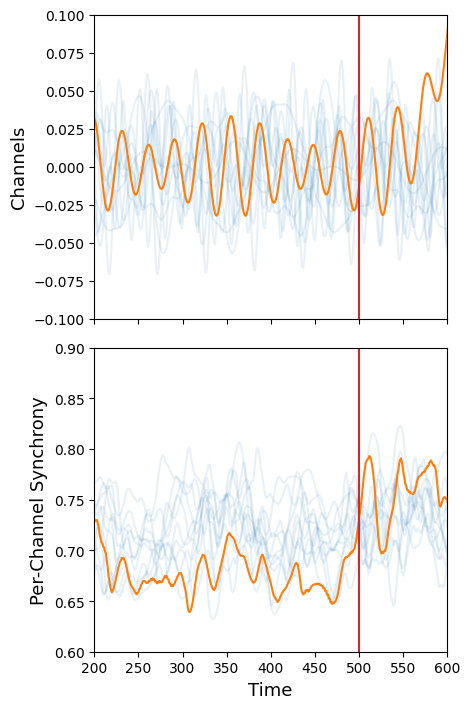

In [6]:
# Generate figures
SMALL_SIZE = 10
MEDIUM_SIZE = 13
BIGGER_SIZE = 20

plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6.4 * 1.5 * 0.5, 4.8 * 1.5))

axs[0].plot(x[:, :11], alpha=0.1, color="tab:blue")
axs[0].plot(x[:, 11], color="tab:orange")
axs[0].axvline(500, color="tab:red")
axs[0].set_ylabel("Channels")
axs[0].set_xlim(200, 600)
axs[0].set_ylim(-0.1, 0.1)

axs[1].plot(r.T[:, :11], alpha=0.1, color="tab:blue")
axs[1].plot(r.T[:, 11], color="tab:orange")
axs[1].axvline(500, color="tab:red")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Per-Channel Synchrony")
axs[1].set_ylim(0.6, 0.9)
axs[0].set_xlim(200, 600)

# fig.suptitle("Imperceptible Sensor Faults have Large Effects on Synchrony")

plt.tight_layout()
plt.savefig("toy_1.pdf")
plt.show()